In [93]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [94]:
df = pd.read_csv('data/raw/spotify_data.csv')
df.head(20)

,Unnamed: 0,track_id,artists,album_name,track_name,popularity,duration_ms,explicit,danceability,energy,...,loudness,mode,speechiness,acousticness,instrumentalness,liveness,valence,tempo,time_signature,track_genre
0,0,5SuOikwiRyPMVoIQDJUgSV,Gen Hoshino,Comedy,Comedy,73,230666,False,0.676,0.4610,...,-6.746,0,0.1430,0.0322,0.000001,0.3580,0.7150,87.917,4,acoustic
1,1,4qPNDBW1i3p13qLCt0Ki3A,Ben Woodward,Ghost (Acoustic),Ghost - Acoustic,55,149610,False,0.420,0.1660,...,-17.235,1,0.0763,0.9240,0.000006,0.1010,0.2670,77.489,4,acoustic
2,2,1iJBSr7s7jYXzM8EGcbK5b,Ingrid Michaelson;ZAYN,To Begin Again,To Begin Again,57,210826,False,0.438,0.3590,...,-9.734,1,0.0557,0.2100,0.000000,0.1170,0.1200,76.332,4,acoustic
3,3,6lfxq3CG4xtTiEg7opyCyx,Kina Grannis,Crazy Rich Asians (Original Motion Picture Sou...,Can't Help Falling In Love,71,201933,False,0.266,0.0596,...,-18.515,1,0.0363,0.9050,0.000071,0.1320,0.1430,181.740,3,acoustic
4,4,5vjLSffimiIP26QG5WcN2K,Chord Overstreet,Hold On,Hold On,82,198853,False,0.618,0.4430,...,-9.681,1,0.0526,0.4690,0.000000,0.0829,0.1670,119.949,4,acoustic
5,5,01MVOl9KtVTNfFiBU9I7dc,Tyrone Wells,Days I Will Remember,Days I Will Remember,58,214240,False,0.688,0.4810,...,-8.807,1,0.1050,0.2890,0.000000,0.1890,0.6660,98.017,4,acoustic
6,6,6Vc5wAMmXdKIAM7WUoEb7N,A Great Big World;Christina Aguilera,Is There Anybody Out There?,Say Something,74,229400,False,0.407,0.1470,...,-8.822,1,0.0355,0.8570,0.000003,0.0913,0.0765,141.284,3,acoustic
7,7,1EzrEOXmMH3G43AXT1y7pA,Jason Mraz,We Sing. We Dance. We Steal Things.,I'm Yours,80,242946,False,0.703,0.4440,...,-9.331,1,0.0417,0.5590,0.000000,0.0973,0.7120,150.960,4,acoustic
8,8,0IktbUcnAGrvD03AWnz3Q8,Jason Mraz;Colbie Caillat,We Sing. We Dance. We Steal Things.,Lucky,74,189613,False,0.625,0.4140,...,-8.700,1,0.0369,0.2940,0.000000,0.1510,0.6690,130.088,4,acoustic
9,9,7k9GuJYLp2AzqokyEdwEw2,Ross Copperman,Hunger,Hunger,56,205594,False,0.442,0.6320,...,-6.770,1,0.0295,0.4260,0.004190,0.0735,0.1960,78.899,4,acoustic


In [95]:
df = df.dropna()

Visualisation of Energy vs Popularity: 


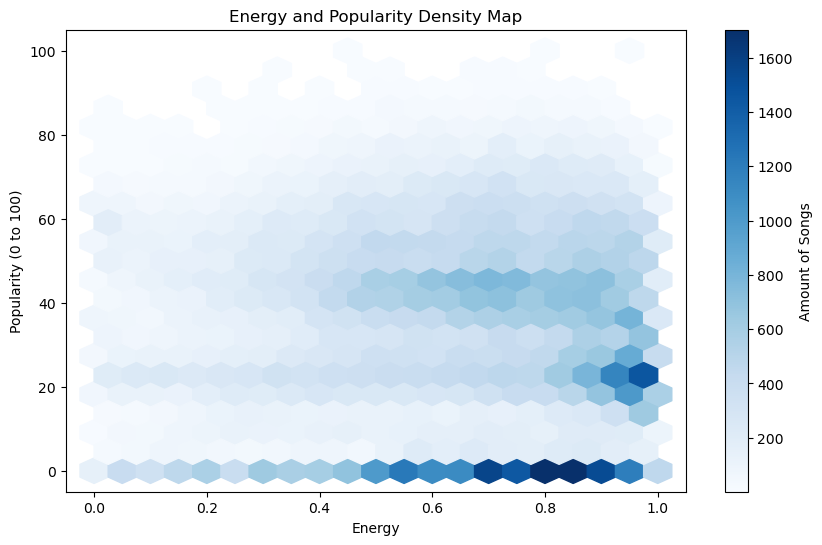

In [96]:
print(f"Visualisation of Energy vs Popularity: ")

plt.figure(figsize=(10, 6))
plt.hexbin(df["energy"], df["popularity"], gridsize=20, cmap='Blues', mincnt=1)
plt.colorbar(label='Amount of Songs')
plt.title("Energy and Popularity Density Map")
plt.xlabel("Energy")
plt.ylabel("Popularity (0 to 100)")
plt.show()


Visualisation of Danceability vs Popularity: 


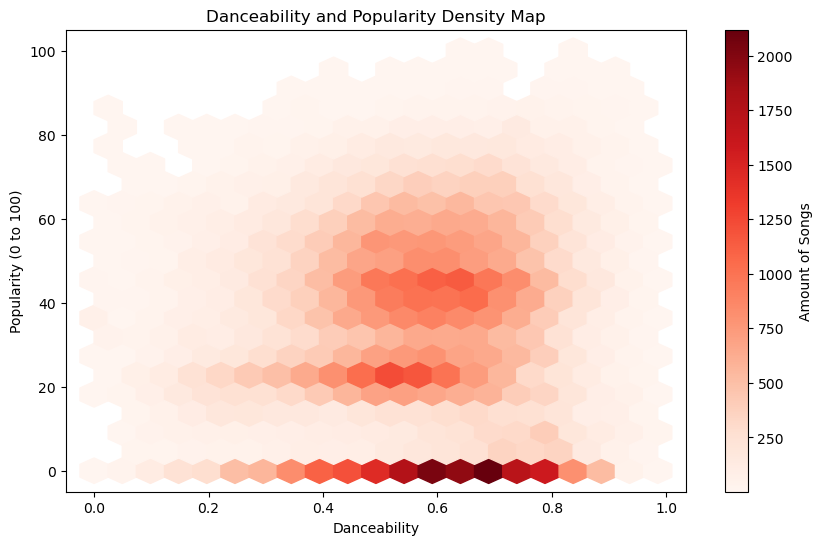

In [97]:
print(f"Visualisation of Danceability vs Popularity: ")

plt.figure(figsize=(10, 6))
plt.hexbin(df["danceability"], df["popularity"], gridsize=20, cmap='Reds', mincnt=1)
plt.colorbar(label='Amount of Songs')
plt.title("Danceability and Popularity Density Map")
plt.xlabel("Danceability")
plt.ylabel("Popularity (0 to 100)")
plt.show()  

Visualisation of Loudness vs Popularity: 


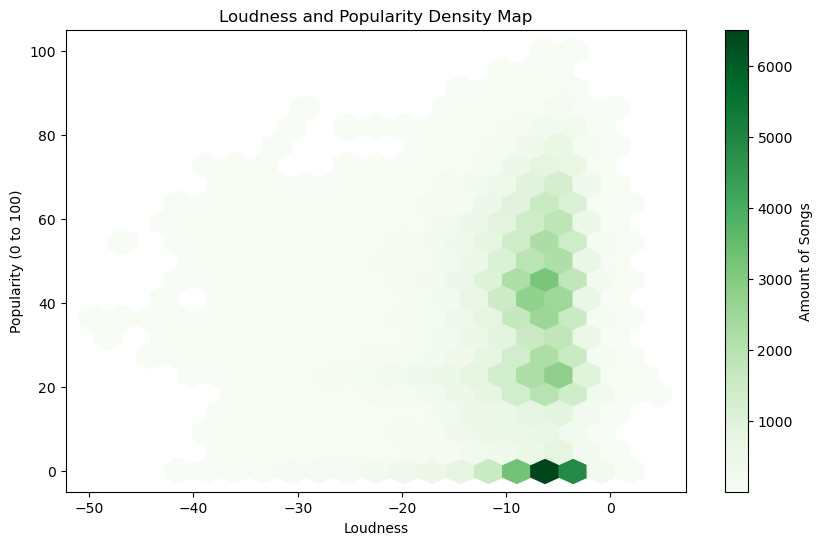

In [98]:
print(f"Visualisation of Loudness vs Popularity: ")

plt.figure(figsize=(10, 6))
plt.hexbin(df["loudness"], df["popularity"], gridsize=20, cmap='Greens', mincnt=1)
plt.colorbar(label='Amount of Songs')
plt.title("Loudness and Popularity Density Map")
plt.xlabel("Loudness")
plt.ylabel("Popularity (0 to 100)")
plt.show()  

Distribution of Popularity Scores: 


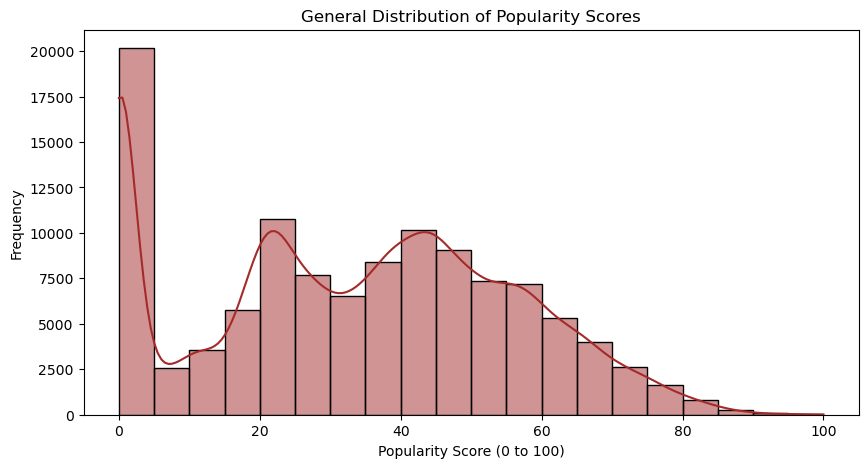

In [99]:
print("Distribution of Popularity Scores: ")
plt.figure(figsize=(10, 5))

sns.histplot(df["popularity"], bins=20, kde=True, color='brown')
plt.title("General Distribution of Popularity Scores")
plt.xlabel("Popularity Score (0 to 100)")
plt.ylabel("Frequency")
plt.show()

Correlation Heatmap of Musical Features: 


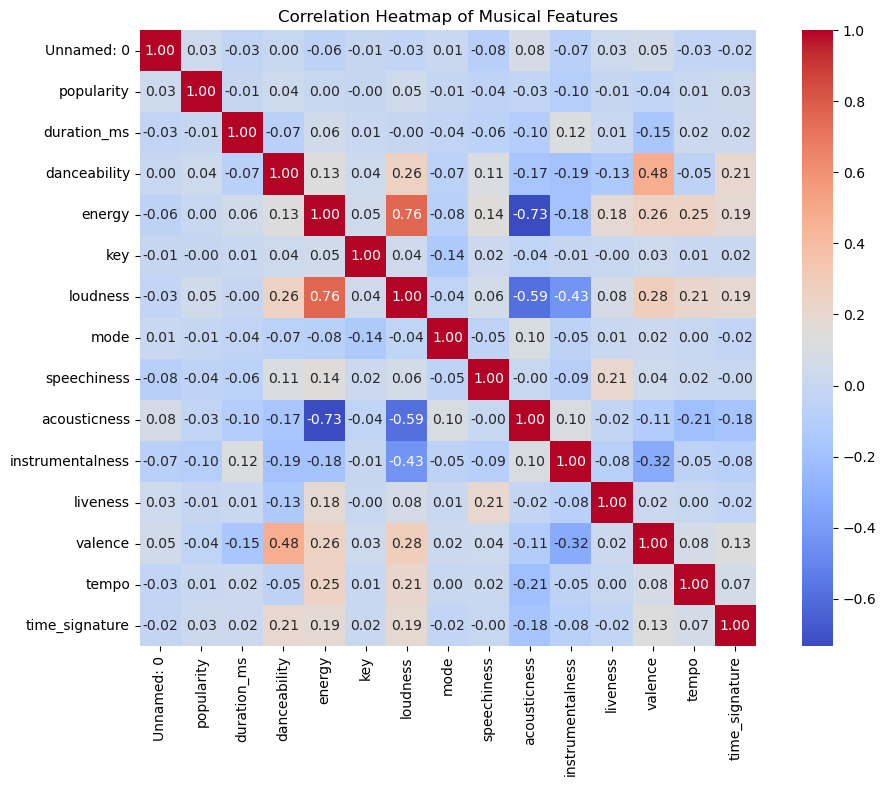

In [100]:
print("Correlation Heatmap of Musical Features: ")

numeric_columns = df.select_dtypes(include=['float64', 'int64'])
plt.figure(figsize=(12, 8))

sns.heatmap(numeric_columns.corr(), annot=True, fmt=".2f", cmap="coolwarm", cbar=True, square=True)
plt.title("Correlation Heatmap of Musical Features")
plt.show()

Outlier Detection for Song Duration: 


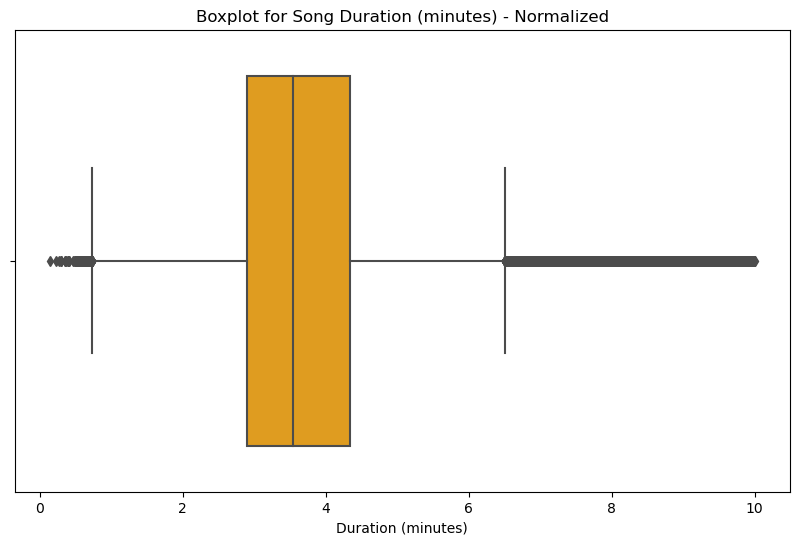

In [101]:
print(f"Outlier Detection for Song Duration: ")
df["duration_min"] = df["duration_ms"] / 60000
normal_songs = df[df["duration_min"] < 10]
plt.figure(figsize=(10, 6))
sns.boxplot(x=normal_songs["duration_min"], color='orange')
plt.title("Boxplot for Song Duration (minutes) - Normalized")
plt.xlabel("Duration (minutes)")
plt.show()

Popularity by Track Mode (Major vs Minor): 


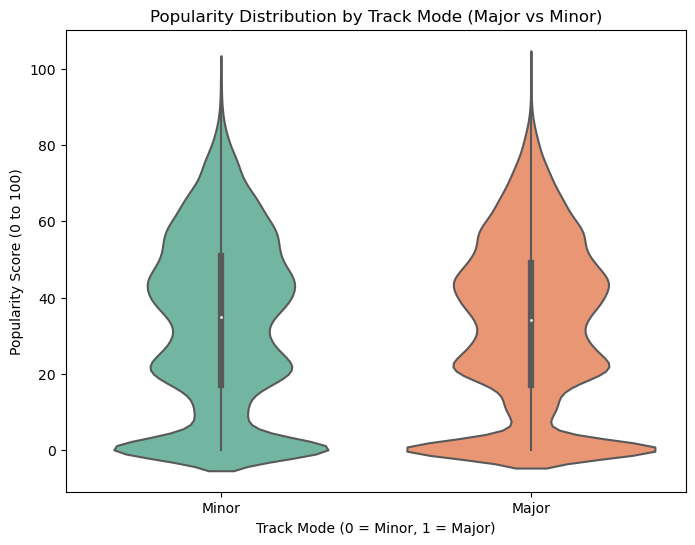

In [102]:
print(f"Popularity by Track Mode (Major vs Minor): ")
plt.figure(figsize=(8, 6))

sns.violinplot(x=df["mode"], y=df["popularity"], palette="Set2")
plt.title("Popularity Distribution by Track Mode (Major vs Minor)")
plt.xlabel("Track Mode (0 = Minor, 1 = Major)")
plt.ylabel("Popularity Score (0 to 100)") 
plt.xticks([0, 1], ['Minor', 'Major'])
plt.show()

In [103]:
# Duration in ms --> Hard to interpret, so we convert it to minutes for better understanding.

df["duration_min"] = df["duration_ms"] / 60000

columns_to_drop = ["duration_ms"]

if "Unnamed: 0" in df.columns:
    df = df.drop(columns=["Unnamed: 0"])
    
    
df = df.drop(columns=columns_to_drop)

display(df.head(20))
    


,track_id,artists,album_name,track_name,popularity,explicit,danceability,energy,key,loudness,mode,speechiness,acousticness,instrumentalness,liveness,valence,tempo,time_signature,track_genre,duration_min
0,5SuOikwiRyPMVoIQDJUgSV,Gen Hoshino,Comedy,Comedy,73,False,0.676,0.4610,1,-6.746,0,0.1430,0.0322,0.000001,0.3580,0.7150,87.917,4,acoustic,3.844433
1,4qPNDBW1i3p13qLCt0Ki3A,Ben Woodward,Ghost (Acoustic),Ghost - Acoustic,55,False,0.420,0.1660,1,-17.235,1,0.0763,0.9240,0.000006,0.1010,0.2670,77.489,4,acoustic,2.493500
2,1iJBSr7s7jYXzM8EGcbK5b,Ingrid Michaelson;ZAYN,To Begin Again,To Begin Again,57,False,0.438,0.3590,0,-9.734,1,0.0557,0.2100,0.000000,0.1170,0.1200,76.332,4,acoustic,3.513767
3,6lfxq3CG4xtTiEg7opyCyx,Kina Grannis,Crazy Rich Asians (Original Motion Picture Sou...,Can't Help Falling In Love,71,False,0.266,0.0596,0,-18.515,1,0.0363,0.9050,0.000071,0.1320,0.1430,181.740,3,acoustic,3.365550
4,5vjLSffimiIP26QG5WcN2K,Chord Overstreet,Hold On,Hold On,82,False,0.618,0.4430,2,-9.681,1,0.0526,0.4690,0.000000,0.0829,0.1670,119.949,4,acoustic,3.314217
5,01MVOl9KtVTNfFiBU9I7dc,Tyrone Wells,Days I Will Remember,Days I Will Remember,58,False,0.688,0.4810,6,-8.807,1,0.1050,0.2890,0.000000,0.1890,0.6660,98.017,4,acoustic,3.570667
6,6Vc5wAMmXdKIAM7WUoEb7N,A Great Big World;Christina Aguilera,Is There Anybody Out There?,Say Something,74,False,0.407,0.1470,2,-8.822,1,0.0355,0.8570,0.000003,0.0913,0.0765,141.284,3,acoustic,3.823333
7,1EzrEOXmMH3G43AXT1y7pA,Jason Mraz,We Sing. We Dance. We Steal Things.,I'm Yours,80,False,0.703,0.4440,11,-9.331,1,0.0417,0.5590,0.000000,0.0973,0.7120,150.960,4,acoustic,4.049100
8,0IktbUcnAGrvD03AWnz3Q8,Jason Mraz;Colbie Caillat,We Sing. We Dance. We Steal Things.,Lucky,74,False,0.625,0.4140,0,-8.700,1,0.0369,0.2940,0.000000,0.1510,0.6690,130.088,4,acoustic,3.160217
9,7k9GuJYLp2AzqokyEdwEw2,Ross Copperman,Hunger,Hunger,56,False,0.442,0.6320,1,-6.770,1,0.0295,0.4260,0.004190,0.0735,0.1960,78.899,4,acoustic,3.426567


Multivariate Analysis of Energy, Valence and Popularity: 


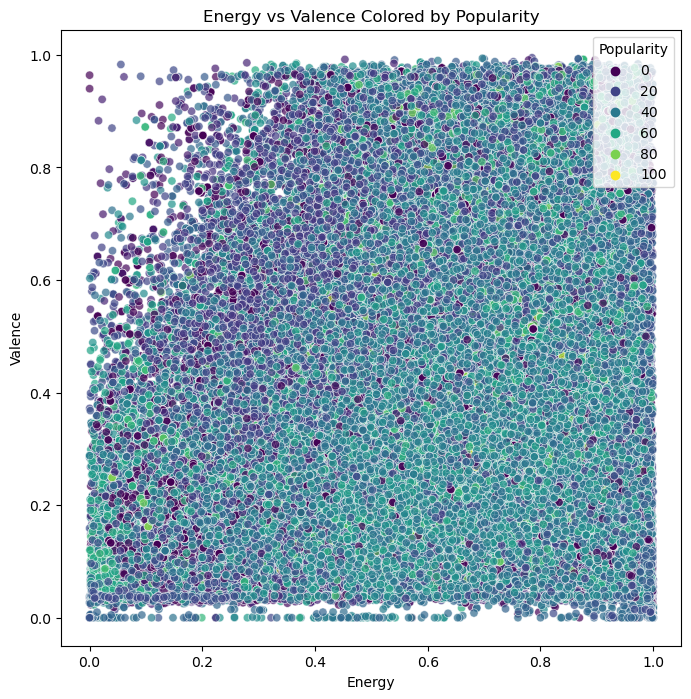

In [107]:
print(f"Multivariate Analysis of Energy, Valence and Popularity: ")
plt.figure(figsize=(8, 8))
sns.scatterplot(x=df["energy"], y=df["valence"], hue=df["popularity"], palette="viridis", alpha=0.7)
plt.title("Energy vs Valence Colored by Popularity")
plt.xlabel("Energy")
plt.ylabel("Valence")
plt.legend(title="Popularity", loc='upper right')
plt.show()

Heatmap of Average Popularity by Energy and Valence: 


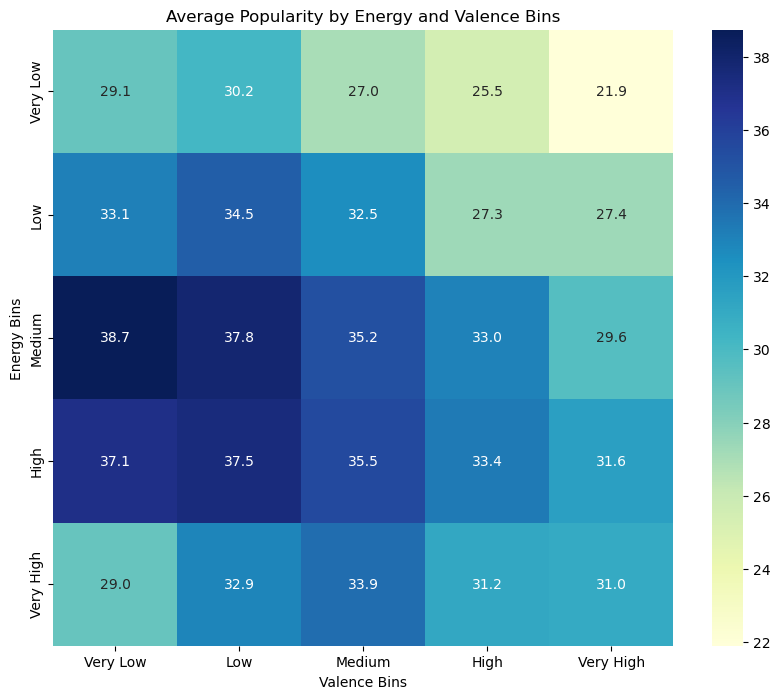

In [109]:
print(f"Heatmap of Average Popularity by Energy and Valence: ")

categories = ["Very Low", "Low", "Medium", "High", "Very High"]
df["energy_bin"] = pd.cut(df["energy"], bins=5, labels=categories)
df["valence_bin"] = pd.cut(df["valence"], bins=5, labels=categories)
heatmap_data = df.groupby(["energy_bin", "valence_bin"])["popularity"].mean().unstack()
plt.figure(figsize=(10, 8))
sns.heatmap(heatmap_data, annot=True, fmt=".1f", cmap="YlGnBu")
plt.title("Average Popularity by Energy and Valence Bins")
plt.xlabel("Valence Bins")
plt.ylabel("Energy Bins")
plt.show()


In [110]:
print("Descriptive Statistics of Key Musical Features: ")
features = ["energy", "danceability", "loudness", "valence", "tempo", "duration_min"]
print(df[features].describe())  

Descriptive Statistics of Key Musical Features: 
              energy   danceability       loudness        valence  \
count  113999.000000  113999.000000  113999.000000  113999.000000   
mean        0.641383       0.566801      -8.258950       0.474066   
std         0.251530       0.173543       5.029357       0.259261   
min         0.000000       0.000000     -49.531000       0.000000   
25%         0.472000       0.456000     -10.013000       0.260000   
50%         0.685000       0.580000      -7.004000       0.464000   
75%         0.854000       0.695000      -5.003000       0.683000   
max         1.000000       0.985000       4.532000       0.995000   

               tempo   duration_min  
count  113999.000000  113999.000000  
mean      122.147695       3.800519  
std        29.978290       1.788268  
min         0.000000       0.143100  
25%        99.218500       2.901100  
50%       122.017000       3.548433  
75%       140.071000       4.358433  
max       243.372000     

Univariate Analysis of Tempo: 


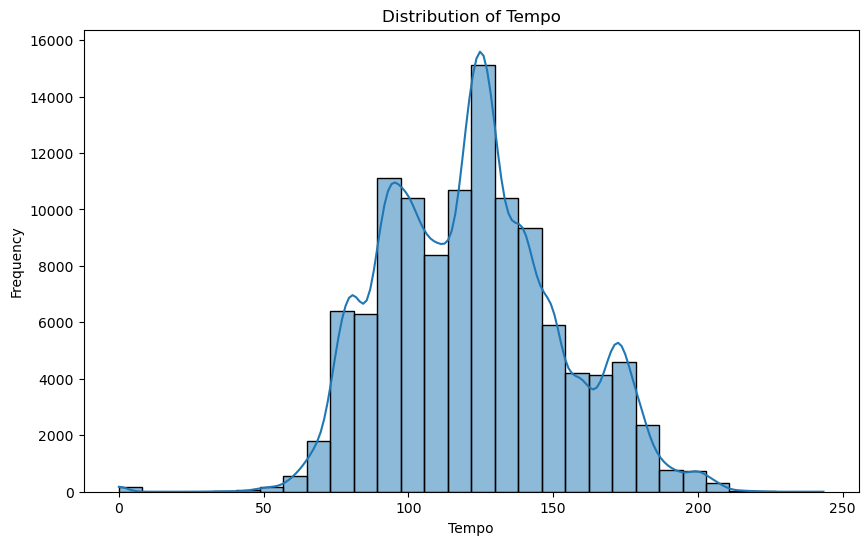

In [111]:
print(f"Univariate Analysis of Tempo: ")
plt.figure(figsize=(10, 6))
sns.histplot(df["tempo"], bins=30, kde=True)
plt.title("Distribution of Tempo")
plt.xlabel("Tempo")
plt.ylabel("Frequency")
plt.show()


Univariate Analysis of Energy: 


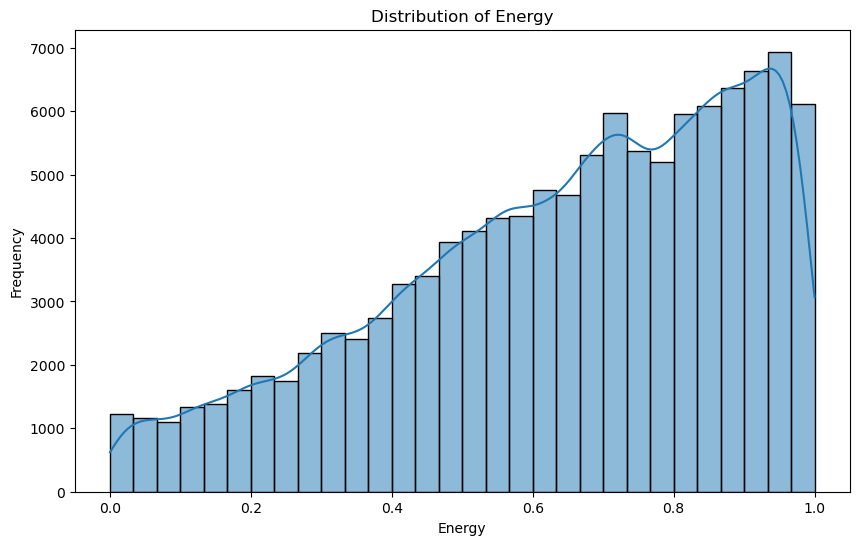

In [112]:
print(f"Univariate Analysis of Energy: ")
plt.figure(figsize=(10, 6))
sns.histplot(df["energy"], bins=30, kde=True)
plt.title("Distribution of Energy")
plt.xlabel("Energy")
plt.ylabel("Frequency")
plt.show()

Univariate Analysis of Danceability: 


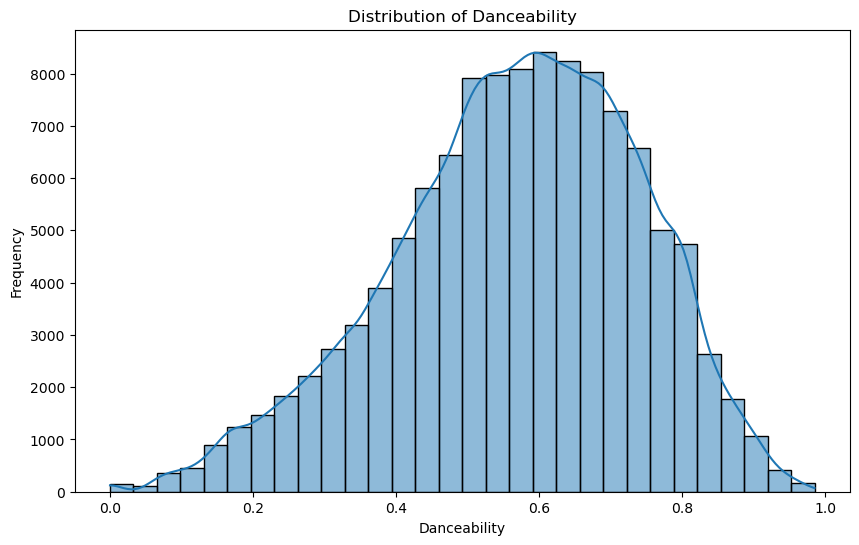

In [114]:
print(f"Univariate Analysis of Danceability: ")
plt.figure(figsize=(10, 6))
sns.histplot(df["danceability"], bins=30, kde=True)
plt.title("Distribution of Danceability")
plt.xlabel("Danceability")
plt.ylabel("Frequency")
plt.show()

Univariate Analysis of Loudness: 


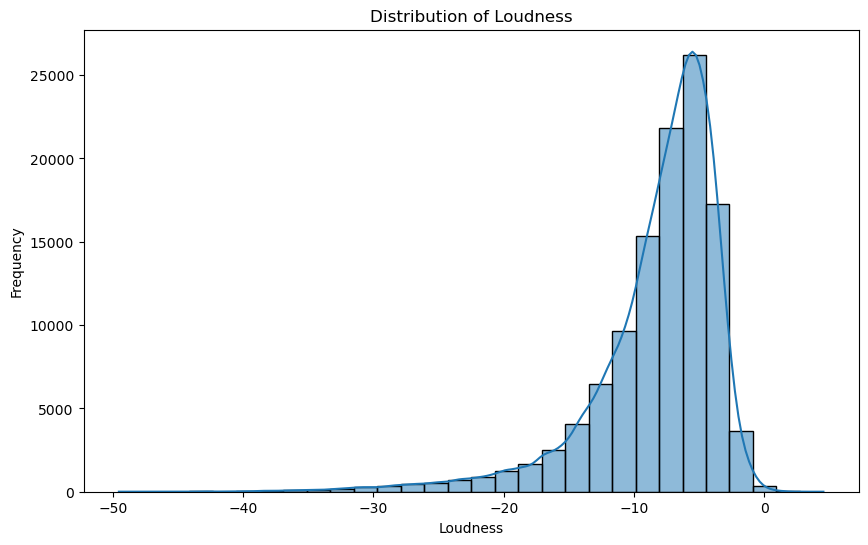

In [115]:
print("Univariate Analysis of Loudness: ")
plt.figure(figsize=(10, 6))
sns.histplot(df["loudness"], bins=30, kde=True)
plt.title("Distribution of Loudness")
plt.xlabel("Loudness")
plt.ylabel("Frequency")
plt.show()

Univariate Analysis of Popularity: 


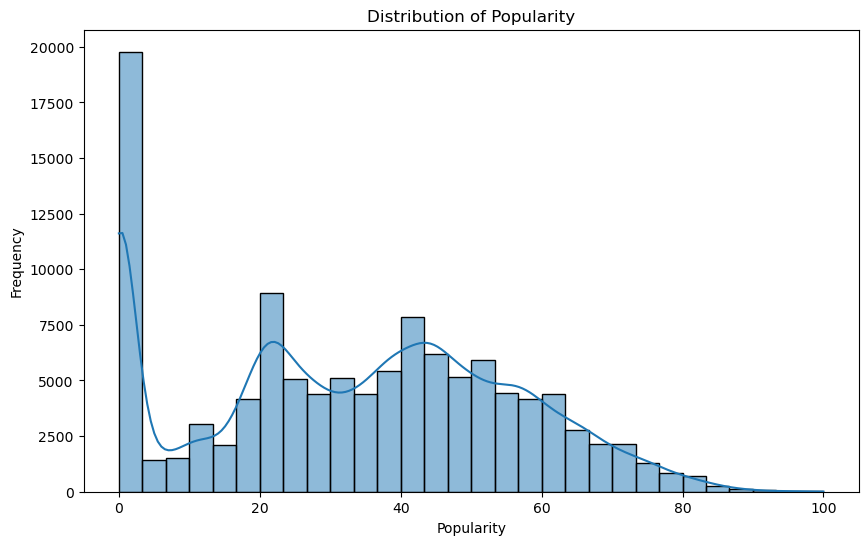

In [116]:
print("Univariate Analysis of Popularity: ")
plt.figure(figsize=(10, 6))
sns.histplot(df["popularity"], bins=30, kde=True)
plt.title("Distribution of Popularity")
plt.xlabel("Popularity")
plt.ylabel("Frequency")
plt.show()